In [69]:
import pandas as pd
from pathlib import Path

DATA = Path("neocp_data/tables")

runs = pd.read_csv(DATA / "neocp_runs.csv", parse_dates=["started_at_utc", "finished_at_utc"])
print(f"{len(runs)} runs total")
runs.tail(10)

411 runs total


,snapshot_id,started_at_utc,finished_at_utc,status,object_count,active_ephemeris_object_count,ephemeris_row_count,error_message
401,20260526T144512Z,2026-05-26 14:45:12.006833+00:00,2026-05-26 14:45:13.211795+00:00,ok,33,31,775,NaN
402,20260526T154513Z,2026-05-26 15:45:13.392487+00:00,2026-05-26 15:45:14.609634+00:00,ok,34,32,800,NaN
403,20260526T164514Z,2026-05-26 16:45:14.728988+00:00,2026-05-26 16:45:15.920452+00:00,ok,34,32,800,NaN
404,20260526T174520Z,2026-05-26 17:45:20.814871+00:00,2026-05-26 17:45:27.161292+00:00,ok,32,30,750,NaN
405,20260526T184529Z,2026-05-26 18:45:29.909597+00:00,2026-05-26 18:45:31.277404+00:00,ok,31,29,725,NaN
406,20260526T194531Z,2026-05-26 19:45:31.404470+00:00,2026-05-26 19:45:32.570995+00:00,ok,32,30,750,NaN
407,20260526T204532Z,2026-05-26 20:45:32.700591+00:00,2026-05-26 20:45:33.990434+00:00,ok,31,29,725,NaN
408,20260526T214534Z,2026-05-26 21:45:34.117823+00:00,2026-05-26 21:45:35.310876+00:00,ok,30,29,725,NaN
409,20260526T224535Z,2026-05-26 22:45:35.485327+00:00,2026-05-26 22:45:37.081286+00:00,ok,29,28,700,NaN
410,20260526T234537Z,2026-05-26 23:45:37.218987+00:00,2026-05-26 23:45:38.429499+00:00,ok,29,28,700,NaN


In [70]:
# latest snapshot of objects
objs = pd.read_csv(DATA / "neocp_objects_history.csv", parse_dates=["fetched_at_utc"])
latest_snap = objs["snapshot_id"].max()
latest = objs[objs["snapshot_id"] == latest_snap].sort_values("score", ascending=False)
print(f"Latest snapshot: {latest_snap}  ({len(latest)} objects)")
latest[["designation", "score", "ra_deg", "dec_deg", "v_mag", "h_mag", "nobs", "arc_days", "not_seen_days"]]

Latest snapshot: 20260526T234537Z  (29 objects)


,designation,score,ra_deg,dec_deg,v_mag,h_mag,nobs,arc_days,not_seen_days
11505,A11CWPw,100,323.6730,-19.4154,18.0,28.7,4,0.02,0.414
11515,C1F2HL5,100,247.0020,-11.7595,22.4,25.5,8,0.07,1.567
11531,NAOCAN7,100,229.3095,-21.9320,21.0,19.7,4,0.10,9.142
11527,C1EYPU5,100,238.1055,3.4280,22.8,24.1,11,1.87,1.745
11526,6EN3D21,100,245.5260,-80.0940,18.6,21.1,3,0.01,2.759
11522,oKr0080,100,352.3635,18.5652,20.2,17.1,3,0.00,3.104
11521,A11CQzo,100,327.4335,-17.2945,20.8,29.8,5,0.05,2.559
11517,C03UYWZ,100,251.0385,13.2293,22.4,23.1,7,2.00,1.550
11516,C1F1TD5,100,236.8020,4.6421,24.1,33.6,4,0.02,1.665
11519,P12nfw2,100,316.3890,-3.4882,21.7,20.3,8,1.73,0.671


In [71]:
# how many snapshots and objects collected over time
counts = objs.groupby("snapshot_id")["designation"].count().reset_index()
counts.columns = ["snapshot_id", "n_objects"]
print(f"Snapshots collected: {len(counts)}")
print(f"Total object-rows: {len(objs)}")
print(f"Unique designations ever seen: {objs['designation'].nunique()}")
counts

Snapshots collected: 411
Total object-rows: 11534
Unique designations ever seen: 267


,snapshot_id,n_objects
0,20260509T230955Z,26
1,20260509T231155Z,26
2,20260509T232939Z,26
3,20260510T002940Z,26
4,20260510T012942Z,26
...,...,...
406,20260526T194531Z,32
407,20260526T204532Z,31
408,20260526T214534Z,30
409,20260526T224535Z,29


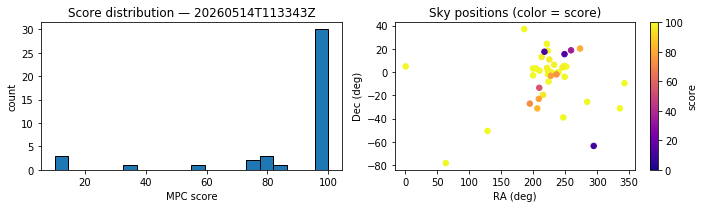

In [63]:
# score distribution in the latest snapshot
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].hist(latest["score"], bins=20, edgecolor="k")
axes[0].set_xlabel("MPC score")
axes[0].set_ylabel("count")
axes[0].set_title(f"Score distribution — {latest_snap}")

axes[1].scatter(latest["ra_deg"], latest["dec_deg"], c=latest["score"], cmap="plasma", s=30, vmin=0, vmax=100)
axes[1].set_xlabel("RA (deg)")
axes[1].set_ylabel("Dec (deg)")
axes[1].set_title("Sky positions (color = score)")
plt.colorbar(axes[1].collections[0], ax=axes[1], label="score")

plt.tight_layout()
plt.show()